In [1]:
import os
os.listdir("../data/raw")

['.gitkeep', '.ipynb_checkpoints', 'student_info.csv']

In [2]:
import pandas as pd
df=pd.read_csv

In [3]:
#load the dataset
import pandas as pd
df=pd.read_csv("../data/raw/student_info.csv")

#printing the shape
print(df.shape)

#printing the column and names
print(df.columns.tolist())

#printing the datatypes
print(df.dtypes)

(1000, 15)
['student_id', 'name', 'gender', 'age', 'grade_level', 'math_score', 'reading_score', 'writing_score', 'attendance_rate', 'parent_education', 'study_hours', 'internet_access', 'lunch_type', 'extra_activities', 'final_result']
student_id              str
name                    str
gender                  str
age                   int64
grade_level           int64
math_score            int64
reading_score         int64
writing_score         int64
attendance_rate     float64
parent_education        str
study_hours         float64
internet_access         str
lunch_type              str
extra_activities        str
final_result            str
dtype: object


In [4]:
#reporting the null and the unique value counts:
#null counts:
print(df.isnull().sum())

#unique-value counts per column
print(df.nunique())

student_id          0
name                0
gender              0
age                 0
grade_level         0
math_score          0
reading_score       0
writing_score       0
attendance_rate     0
parent_education    0
study_hours         0
internet_access     0
lunch_type          0
extra_activities    0
final_result        0
dtype: int64
student_id          1000
name                1000
gender                 3
age                    3
grade_level            4
math_score            50
reading_score         50
writing_score         50
attendance_rate     1000
parent_education       4
study_hours         1000
internet_access        2
lunch_type             2
extra_activities       2
final_result           2
dtype: int64


## Dataset information
**Dataset:** Student Academic Performance Dataset

**Source:** Kaggle-Student Academic Performance Dataset

**Lisence:** CC BY-SA 4.0

**Reason for the selection**

i chose this because it has 200+ records above what was asked and also it contains the numerical and categorical columns to ensure the practice of good data analysis.
i also chose this dataset because i wanted something that would be simple and easy to learn since we are getting to learn and understand these features of datasets.
 

In [5]:
#seeing if there are some duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
#looking for all gender available in dataset
df["gender"]

0       Other
1        Male
2       Other
3       Other
4        Male
        ...  
995    Female
996    Female
997     Other
998     Other
999      Male
Name: gender, Length: 1000, dtype: str

In [7]:
#grouping the data by gender and doing the aggregation statistics on it
group_stats = df.groupby("gender").agg(
    avg_grade=("grade_level", "mean"),
    min_grade=("grade_level", "min"),
    max_grade=("grade_level", "max")
).reset_index()
#printing the dataframe of the groupeg data
print(group_stats)

   gender  avg_grade  min_grade  max_grade
0  Female  10.509202          9         12
1    Male  10.436620          9         12
2   Other  10.476489          9         12


In [8]:
#check the shape of datafframe before merging
print("before mergeing:",df.shape)

before mergeing: (1000, 15)


In [9]:
#then here we can merge the df
df= df.merge(group_stats, on="gender", how="left")
print(df)

    student_id          name  gender  age  grade_level  math_score  \
0           S1     Student_1   Other   17           10          74   
1           S2     Student_2    Male   17           12          99   
2           S3     Student_3   Other   17            9          59   
3           S4     Student_4   Other   17           12          70   
4           S5     Student_5    Male   15            9          85   
..         ...           ...     ...  ...          ...         ...   
995       S996   Student_996  Female   15           10          76   
996       S997   Student_997  Female   17           12          83   
997       S998   Student_998   Other   16           10          60   
998       S999   Student_999   Other   17            9          94   
999      S1000  Student_1000    Male   17            9          96   

     reading_score  writing_score  attendance_rate parent_education  \
0               61             90        94.660002         Master's   
1               7

In [10]:
print("after megerging",df.shape)

after megerging (1000, 18)


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(df.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['student_id', 'name', 'gender', 'age', 'grade_level', 'math_score',
       'reading_score', 'writing_score', 'attendance_rate', 'parent_education',
       'study_hours', 'internet_access', 'lunch_type', 'extra_activities',
       'final_result', 'avg_grade', 'min_grade', 'max_grade'],
      dtype='str')>


In [13]:
print("Shape before melt:", df.shape)

Shape before melt: (1000, 18)


In [14]:
melted_df=df.melt(
    id_vars=["gender"],
    value_vars=["math_score","reading_score","writing_score"],
    var_name="subjects",
    value_name="scores"
)
print(melted_df)

      gender       subjects  scores
0      Other     math_score      74
1       Male     math_score      99
2      Other     math_score      59
3      Other     math_score      70
4       Male     math_score      85
...      ...            ...     ...
2995  Female  writing_score      55
2996  Female  writing_score      98
2997   Other  writing_score      92
2998   Other  writing_score      97
2999    Male  writing_score      93

[3000 rows x 3 columns]


In [15]:
print("Shape after melt:", melted_df.shape)

Shape after melt: (3000, 3)


In [16]:
#for numpy-based computation
#pull one column:
df["math_score"]

#changing the pandas type to the numpy array
scores=df["math_score"].to_numpy()
print(type(scores))

<class 'numpy.ndarray'>


In [17]:
# perform vector by the normalization
import numpy as np
minimum = np.min(scores)
maximum = np.max(scores)

#perfom vectorization
normalized_scores=(scores-minimum)/(maximum-minimum)
#print(normalized_scores)

#Print the mean, standard deviation, min, and max of the result
print("Mean:", np.mean(normalized_scores))
print("Standard deviation:", np.std(normalized_scores))
print("Minimum:", np.min(normalized_scores))
print("Maximum:", np.max(normalized_scores))

Mean: 0.5135714285714286
Standard deviation: 0.29177948275298904
Minimum: 0.0
Maximum: 1.0


In [18]:
df["math_score_normalized"] = normalized_scores
print(df[["math_score", "math_score_normalized"]].head())

   math_score  math_score_normalized
0          74               0.489796
1          99               1.000000
2          59               0.183673
3          70               0.408163
4          85               0.714286


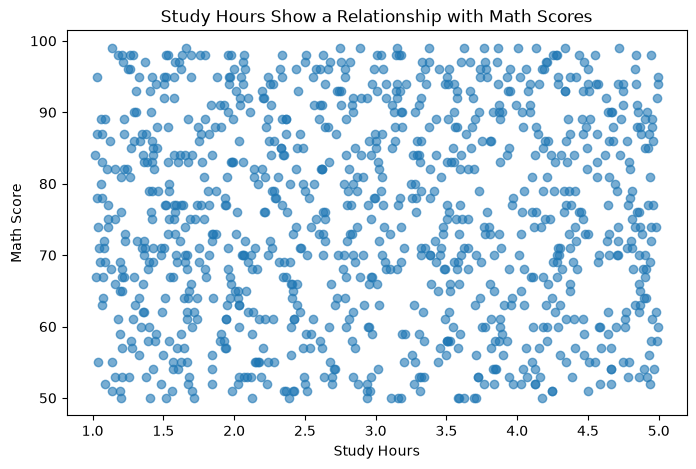

In [19]:
import matplotlib.pyplot as plt

#identify the figure size width and height
plt.figure(figsize=(8, 5))

#identify the y/x axis
plt.scatter(
    df["study_hours"],
    df["math_score"],
    alpha=0.6
)

#name the x/y axis to clarify them
plt.xlabel("Study Hours")
plt.ylabel("Math Score")

# the title of the plot
plt.title("Study Hours Show a Relationship with Math Scores")

plt.savefig(
    "../reports/a2_chart1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

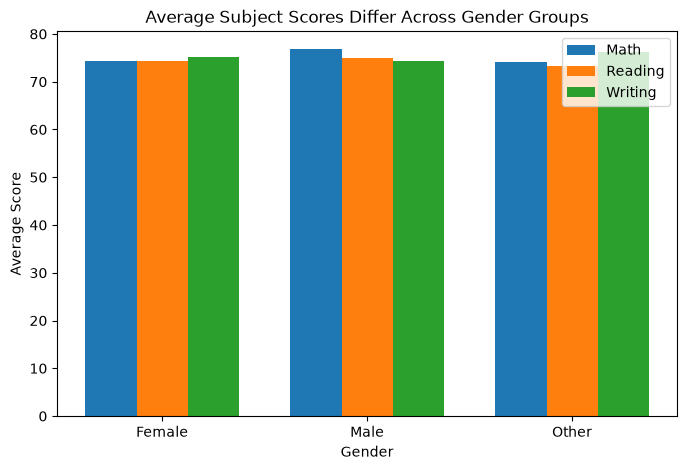

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate average scores by gender
gender_scores = df.groupby("gender")[
    ["math_score", "reading_score", "writing_score"]
].mean()

# Create figure
plt.figure(figsize=(8, 5))

# Positions for gender groups
x = np.arange(len(gender_scores.index))
width = 0.25

# Create bars
plt.bar(
    x - width,
    gender_scores["math_score"],
    width,
    label="Math"
)

plt.bar(
    x,
    gender_scores["reading_score"],
    width,
    label="Reading"
)

plt.bar(
    x + width,
    gender_scores["writing_score"],
    width,
    label="Writing"
)

# Labels
plt.xlabel("Gender")
plt.ylabel("Average Score")

# Gender names
plt.xticks(x, gender_scores.index)

# Legend
plt.legend()

# Change this based on your actual finding
plt.title("Average Subject Scores Differ Across Gender Groups")

# Save
plt.savefig(
    "../reports/a2_chart2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [21]:
import os

print(os.getcwd())

C:\Users\hp\Desktop\klab-ai-abijuru\notebooks


In [22]:
df.to_csv("../data/processed/student_info_cleaned.csv", index=False)

In [23]:
import os

print(os.path.exists("data/processed/student_info_cleaned.csv"))

False


In [24]:

print(os.getcwd())

C:\Users\hp\Desktop\klab-ai-abijuru\notebooks


In [25]:
print(os.path.exists("../data"))
print(os.path.exists("../data/processed"))

True
True


In [26]:
import os

print(os.listdir("../data/processed"))

['.gitkeep', 'student_info_cleaned.csv']


In [27]:
df.to_csv("../data/processed/student_info_cleaned.csv", index=False)

In [28]:
print(os.path.exists("../data/processed/student_info_cleaned.csv"))

True


# Student Performance Analysis

## Question

This analysis explored the question: How do student grades differ by gender, and what does the overall distribution of grades look like?

The dataset contains information about student performance, including student demographic and academic information. I was interested in examining whether there were noticeable differences in grades between groups of students.

## Findings

The analysis showed that student grades varied across the dataset. When students were grouped by gender, the average, minimum, and maximum grades showed differences between the groups.

The first chart shows the distribution of student grades across the dataset. This helps show how the grades are spread and whether most students are concentrated around particular grade values.

## Chart 1: Grade Distribution(a2_chart1.png)

The first chart compares student performance by study_hours. The results, chart shows that students who reported more study hours tended to have higher mathematics performance in math subject. 

## Chart 2: Grades by Gender(a2_chart2.png)

Overall, the analysis suggests that The gender comparison shows differences in performance across subjects. Each gender group appeared to perform better in some subjects than in others, suggesting that subject performance varied across the gender groups ,and this showed that every gender had one subject to perform well than other gender. The results provide a useful summary of the patterns in this dataset, although they do not explain the reasons behind those patterns.

## Limitation

One limitation of this analysis is that it only shows patterns and relationships in the dataset; it does not prove that study hours directly cause better math performance. Other factors, such as teaching methods, attendance, prior knowledge, or study conditions, may also affect students' grades. In addition, the gender comparison does not explain why students performed differently in particular subjects.

## Conclusion

The analysis provided an overview of student performance and showed differences in grades across the groups examined. The charts made these patterns easier to compare and interpret. Further analysis could examine additional variables to better understand the factors associated with student performance.